In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load cleaned encoded data
df = pd.read_csv("../data/cleaned_data.csv")

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df["readmitted_binary"].value_counts())

Dataset loaded!
Shape: (99493, 46)

Target distribution:
readmitted_binary
0    88324
1    11169
Name: count, dtype: int64


In [2]:
# Separate features and target
x = df.drop(columns=["readmitted_binary"])
y = df["readmitted_binary"]

print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

# Apply SMOTE to handle class imbalance on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm, = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE")
print(f"Training set: {X_train_sm.shape}")
print(f"Target distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())



Features shape: (99493, 45)
Target shape: (99493,)

Training set: (79594, 45)
Testing set: (19899, 45)

After SMOTE
Training set: (141318, 45)
Target distribution after SMOTE:
readmitted_binary
0    70659
1    70659
Name: count, dtype: int64


In [3]:
# Train XGBoost model
print("Training XGBoost model...")
print("This will take 2-3 minutes...")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric="auc",
    early_stopping_rounds=20,
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nModel Training complete!")

Training XGBoost model...
This will take 2-3 minutes...
[0]	validation_0-auc:0.57889
[33]	validation_0-auc:0.58182

Model Training complete!


In [5]:
# Better feature selection - use most important numeric features
feature_cols = [
    'time_in_hospital',
    'num_lab_procedures', 
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'age',
    'race',
    'gender',
    'insulin',
    'diabetesMed',
    'change',
    'A1Cresult',
    'max_glu_serum'
]

x = df[feature_cols]
y = df["readmitted_binary"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Training with {len(feature_cols)} key features")
print(F"Training set after SMOTE: {X_train_sm.shape}")

# Train improved model
# Train improved model
print("\nTraining XGBoost model...")

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("\nModel training complete!")

Training with 19 key features
Training set after SMOTE: (141318, 19)

Training XGBoost model...
[0]	validation_0-auc:0.53415
[33]	validation_0-auc:0.55470

Model training complete!


In [6]:
# Use ALL columns including diagnosis and medication columns
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Training set after SMOTE: {X_train_sm.shape}")

# Train with better parameters
print("Training XGBoost model...")

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("\nModel training complete!")

Training set after SMOTE: (141318, 45)
Training XGBoost model...
[0]	validation_0-auc:0.54211
[100]	validation_0-auc:0.59223
[200]	validation_0-auc:0.60032
[300]	validation_0-auc:0.60498
[400]	validation_0-auc:0.61019
[499]	validation_0-auc:0.61240

Model training complete!


In [9]:
# Feature engineering - create better predictors
df_fe = df.copy()

# Create new meaningful features
df_fe['total_visits'] = df_fe['number_outpatient'] + df_fe['number_emergency'] + df_fe['number_inpatient']
df_fe['procedures_per_day'] = df_fe['num_procedures'] / (df_fe['time_in_hospital'] + 1)
df_fe['medications_per_day'] = df_fe['num_medications'] / (df_fe['time_in_hospital'] + 1)
df_fe['lab_per_day'] = df_fe['num_lab_procedures'] / (df_fe['time_in_hospital'] + 1)
df_fe['is_emergency'] = (df_fe['number_emergency'] > 0).astype(int)
df_fe['is_repeat_patient'] = (df_fe['number_inpatient'] > 0).astype(int)
df_fe['high_medications'] = (df_fe['num_medications'] > 15).astype(int)
df_fe['long_stay'] = (df_fe['time_in_hospital'] > 7).astype(int)

X = df_fe.drop(columns=['readmitted_binary'])
y = df_fe['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Features: {X.shape[1]}")
print("Training XGBoost model...")

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("\nModel training complete!")

Features: 53
Training XGBoost model...
[0]	validation_0-auc:0.57602
[38]	validation_0-auc:0.59647

Model training complete!


In [10]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Evaluate model
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test,y_pred_proba)
print(f"AUC_ROC Score: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save model
import joblib
joblib.dump(model, "../models/readmission_model.pk1")

# Save feature names
feature_names= list(X.columns)
joblib.dump(feature_names, "../models/feature_names.pk1")

print("\nModel saved to models/readmission_model.pkl")

AUC_ROC Score: 0.6010

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88     17665
           1       0.16      0.20      0.17      2234

    accuracy                           0.79     19899
   macro avg       0.52      0.53      0.53     19899
weighted avg       0.81      0.79      0.80     19899


Model saved to models/readmission_model.pkl


In [11]:
# Calculate scale_pos_weight
# Calculate scale_pos_weight
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale = negative / positive
print(f"scale_pos_weight: {scale:.2f}")

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model2 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

model2.fit(
    X_train2, y_train2,
    eval_set=[(X_test2, y_test2)],
    verbose=100
)

y_pred2 = model2.predict(X_test2)
y_pred_proba2 = model2.predict_proba(X_test2)[:, 1]
auc2 = roc_auc_score(y_test2, y_pred_proba2)
print(f"\nAUC-ROC Score: {auc2:.4f}")
print(classification_report(y_pred2, y_test2))

scale_pos_weight: 7.91
[0]	validation_0-auc:0.64928
[100]	validation_0-auc:0.67655
[128]	validation_0-auc:0.67626

AUC-ROC Score: 0.6767
              precision    recall  f1-score   support

           0       0.67      0.93      0.78     12715
           1       0.58      0.18      0.28      7184

    accuracy                           0.66     19899
   macro avg       0.63      0.55      0.53     19899
weighted avg       0.64      0.66      0.60     19899



In [27]:
# Load the properly encoded dataset for XGBoost
df_xgb = pd.read_csv('../data/cleaned_data.csv')

X = df_xgb.drop(columns=['readmitted_binary'])
y = df_xgb['readmitted_binary']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:")
print(y.value_counts())

Features: 45
Target distribution:
readmitted_binary
0    88324
1    11169
Name: count, dtype: int64


In [28]:
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ==========================================
# CALCULATE SCALE_POS_WEIGHT
# ==========================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# ==========================================
# XGBOOST MODEL
# ==========================================

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',

    n_estimators=1000,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=5,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=1,

    reg_alpha=1,
    reg_lambda=2,

    scale_pos_weight=scale_pos_weight,

    early_stopping_rounds=50,

    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# ==========================================
# PREDICT PROBABILITIES
# ==========================================

y_prob = model.predict_proba(X_test)[:, 1]

# ==========================================
# ROC AUC SCORE
# ==========================================

auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC Score: {auc:.4f}")

# ==========================================
# FIND BEST THRESHOLD USING F1 SCORE
# ==========================================

thresholds = np.arange(0.10, 0.90, 0.01)

best_threshold = 0.60
best_f1 = 0

for t in thresholds:

    y_pred_temp = (y_prob >= t).astype(int)

    current_f1 = f1_score(y_test, y_pred_temp)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

# ==========================================
# FINAL PREDICTIONS
# ==========================================

y_pred = (y_prob >= best_threshold).astype(int)

# ==========================================
# METRICS
# ==========================================

accuracy = (y_pred == y_test).mean()

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("\n==============================")
print("FINAL MODEL RESULTS")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# ==========================================
# CONFUSION MATRIX
# ==========================================

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))

scale_pos_weight: 7.91
[0]	validation_0-auc:0.61616
[100]	validation_0-auc:0.67019
[200]	validation_0-auc:0.67447
[300]	validation_0-auc:0.67636
[400]	validation_0-auc:0.67751
[500]	validation_0-auc:0.67839
[600]	validation_0-auc:0.67890
[700]	validation_0-auc:0.67935
[772]	validation_0-auc:0.67930

ROC-AUC Score: 0.6795

Best Threshold: 0.56
Best F1 Score: 0.2860

FINAL MODEL RESULTS
Accuracy : 0.7578
Precision: 0.2137
Recall   : 0.4320
F1 Score : 0.2860

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.85     17665
           1       0.21      0.43      0.29      2234

    accuracy                           0.76     19899
   macro avg       0.57      0.62      0.57     19899
weighted avg       0.84      0.76      0.79     19899


Confusion Matrix:

[[14115  3550]
 [ 1269   965]]


In [15]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load original clean readable data (before label encoding)
df_cat = pd.read_csv('../data/clean_data_readable.csv')

# ==========================================
# DIAGNOSIS CODE GROUPING
# ==========================================
def group_diagnosis(diag):
    try:
        code = str(diag)
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        val = float(code)
        if 390 <= val <= 459 or val == 785:
            return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:
            return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:
            return 'Digestive'
        elif val == 250:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

df_cat['diag_1_group'] = df_cat['diag_1'].apply(group_diagnosis)
df_cat['diag_2_group'] = df_cat['diag_2'].apply(group_diagnosis)
df_cat['diag_3_group'] = df_cat['diag_3'].apply(group_diagnosis)

# ==========================================
# FEATURE ENGINEERING
# ==========================================
df_cat['total_visits'] = df_cat['number_outpatient'] + df_cat['number_emergency'] + df_cat['number_inpatient']
df_cat['medications_per_day'] = df_cat['num_medications'] / (df_cat['time_in_hospital'] + 1)
df_cat['lab_per_day'] = df_cat['num_lab_procedures'] / (df_cat['time_in_hospital'] + 1)
df_cat['is_emergency'] = (df_cat['number_emergency'] > 0).astype(int)
df_cat['is_repeat_patient'] = (df_cat['number_inpatient'] > 0).astype(int)
df_cat['high_medications'] = (df_cat['num_medications'] > 15).astype(int)
df_cat['long_stay'] = (df_cat['time_in_hospital'] > 7).astype(int)

# ==========================================
# PREPARE FEATURES
# ==========================================
drop_cols = ['readmitted_binary', 'diag_1', 'diag_2', 'diag_3']
X = df_cat.drop(columns=drop_cols)
y = df_cat['readmitted_binary']

# Define categorical columns for CatBoost
cat_cols = ['race', 'gender', 'age', 'medical_specialty',
            'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
            'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
            'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
            'tolazamide', 'examide', 'citoglipton', 'insulin',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone', 'change', 'diabetesMed',
            'diag_1_group', 'diag_2_group', 'diag_3_group']

# Get indices of categorical columns
cat_indices = [X.columns.tolist().index(c) for c in cat_cols if c in X.columns]

print(f"Total features: {X.shape[1]}")
print(f"Categorical features: {len(cat_indices)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Total features: 52
Categorical features: 34
Training set: (79594, 52)
Testing set: (19899, 52)


In [29]:
# =========================================================
# CATBOOST PIPELINE USING RAW CATEGORICAL VARIABLES
# =========================================================

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    average_precision_score
)

# =========================================================
# LOAD RAW DATASET
# =========================================================

df = pd.read_csv('../data/diabetic_data.csv')

print("Original Shape:", df.shape)

# =========================================================
# CREATE TARGET VARIABLE
# =========================================================

# Positive class:
# readmitted within <30 days

df['readmitted_binary'] = (
    df['readmitted'] == '<30'
).astype(int)

# =========================================================
# DROP USELESS / LEAKAGE COLUMNS
# =========================================================

drop_cols = [

    'encounter_id',
    'patient_nbr',

    'readmitted'

]

df.drop(columns=drop_cols, inplace=True)

# =========================================================
# REPLACE MISSING VALUES
# =========================================================

df.replace('?', np.nan, inplace=True)

# =========================================================
# HANDLE DIAGNOSIS CODES
# =========================================================

def group_diagnosis(diag):

    try:

        diag = float(diag)

        if 390 <= diag <= 459:
            return 'Circulatory'

        elif 460 <= diag <= 519:
            return 'Respiratory'

        elif 520 <= diag <= 579:
            return 'Digestive'

        elif 250 <= diag < 251:
            return 'Diabetes'

        elif 800 <= diag <= 999:
            return 'Injury'

        else:
            return 'Other'

    except:
        return 'Other'

df['diag_1_group'] = df['diag_1'].apply(group_diagnosis)
df['diag_2_group'] = df['diag_2'].apply(group_diagnosis)
df['diag_3_group'] = df['diag_3'].apply(group_diagnosis)

# =========================================================
# DROP ORIGINAL DIAGNOSIS COLUMNS
# =========================================================

df.drop(
    columns=['diag_1', 'diag_2', 'diag_3'],
    inplace=True
)

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

# Categorical columns
cat_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

# Fill categorical NaNs
for col in cat_cols:

    df[col] = df[col].fillna('Unknown')

# Numerical columns
num_cols = df.select_dtypes(
    exclude=['object']
).columns.tolist()

for col in num_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )

# =========================================================
# FEATURE ENGINEERING
# =========================================================

print("\nCreating engineered features...")

df['total_visits'] = (
    df['number_outpatient']
    + df['number_emergency']
    + df['number_inpatient']
)

df['emergency_ratio'] = (
    df['number_emergency']
    / (df['total_visits'] + 1)
)

df['inpatient_ratio'] = (
    df['number_inpatient']
    / (df['total_visits'] + 1)
)

df['medication_per_visit'] = (
    df['num_medications']
    / (df['total_visits'] + 1)
)

df['lab_procedure_ratio'] = (
    df['num_lab_procedures']
    / (df['time_in_hospital'] + 1)
)

# =========================================================
# FEATURES / TARGET
# =========================================================

X = df.drop(columns=['readmitted_binary'])

y = df['readmitted_binary']

print("\nDataset Shape:", X.shape)

print("\nTarget Distribution:")
print(y.value_counts())

# =========================================================
# IDENTIFY CATEGORICAL COLUMNS
# =========================================================

cat_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

print("\nCategorical Columns:")
print(cat_cols)

# =========================================================
# CONVERT TO STRING
# =========================================================

for col in cat_cols:

    X[col] = X[col].astype(str)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

# =========================================================
# GET CATEGORICAL FEATURE INDICES
# =========================================================

cat_feature_indices = [

    X_train.columns.get_loc(col)

    for col in cat_cols
]

# =========================================================
# CATBOOST MODEL
# =========================================================

print("\nTraining CatBoost model...\n")

model_cat = CatBoostClassifier(

    loss_function='Logloss',

    eval_metric='AUC',

    iterations=3000,

    learning_rate=0.01,

    depth=4,

    l2_leaf_reg=10,

    random_strength=2,

    border_count=128,

    subsample=0.8,

    class_weights=[1,3],

    early_stopping_rounds=100,

    random_seed=42,

    verbose=100
)

# =========================================================
# TRAIN MODEL
# =========================================================

model_cat.fit(

    X_train,
    y_train,

    cat_features=cat_feature_indices,

    eval_set=(X_test, y_test),

    use_best_model=True,

    plot=False
)

# =========================================================
# PREDICT PROBABILITIES
# =========================================================

y_prob = model_cat.predict_proba(X_test)[:, 1]

# =========================================================
# ROC-AUC
# =========================================================

roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC Score: {roc_auc:.4f}")

# =========================================================
# PR-AUC
# =========================================================

pr_auc = average_precision_score(y_test, y_prob)

print(f"PR-AUC Score : {pr_auc:.4f}")

# =========================================================
# FIND BEST THRESHOLD
# =========================================================

thresholds = np.arange(0.10, 0.90, 0.01)

best_threshold = 0.50

best_f1 = 0

for t in thresholds:

    y_pred_temp = (
        y_prob >= t
    ).astype(int)

    current_f1 = f1_score(
        y_test,
        y_pred_temp
    )

    if current_f1 > best_f1:

        best_f1 = current_f1

        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

print(f"Best F1 Score: {best_f1:.4f}")

# =========================================================
# FINAL PREDICTIONS
# =========================================================

y_pred = (
    y_prob >= best_threshold
).astype(int)

# =========================================================
# FINAL METRICS
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("\n====================================")

print("FINAL CATBOOST RESULTS")

print("====================================")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

print("\nConfusion Matrix:\n")

print(confusion_matrix(
    y_test,
    y_pred
))

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model_cat.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False
)

print("\nTop 20 Important Features:\n")

print(feature_importance.head(20))

Original Shape: (101766, 50)

Creating engineered features...

Dataset Shape: (101766, 52)

Target Distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Categorical Columns:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']

Training CatBoost model...

0:	test: 0.6020940	best: 0.6020940 (0)	total: 311ms	remaining: 15m 33s
100:	test: 0.6453673	best: 0.6454820 (97)	total: 22.6s	remaining: 10m 47s
200:	test: 0.6488326	best: 0.6488326 (199)	total: 44.8s	remaining:

In [50]:
print(model_cat.get_best_score())

{'learn': {'Logloss': 0.5379000933827413}, 'validation': {'Logloss': 0.5433910341490368, 'AUC': 0.6835205528750653}}


In [51]:
print(recall)

0.48392778511668866


In [30]:
print(accuracy)

0.7358258818905374


In [34]:
from sklearn.metrics import (
    recall_score, precision_score, f1_score, 
    accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
import numpy as np

# ==========================================
# CATBOOST METRICS (already have y_pred, y_prob)
# ==========================================
cat_accuracy = accuracy_score(y_test, y_pred)
cat_precision = precision_score(y_test, y_pred)
cat_recall = recall_score(y_test, y_pred)
cat_f1 = f1_score(y_test, y_pred)
cat_auc = roc_auc_score(y_test, y_prob)
cat_pr_auc = average_precision_score(y_test, y_prob)
cat_cm = confusion_matrix(y_test, y_pred)

# ==========================================
# XGBOOST METRICS (retrain quickly)
# ==========================================
import xgboost as xgb
from sklearn.model_selection import train_test_split

df_xgb = pd.read_csv('../data/cleaned_data.csv')
X_xgb = df_xgb.drop(columns=['readmitted_binary'])
y_xgb = df_xgb['readmitted_binary']

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb
)

negative = (y_train_xgb == 0).sum()
positive = (y_train_xgb == 1).sum()
scale = negative / positive

model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=1,
    reg_lambda=2,
    scale_pos_weight=scale,
    early_stopping_rounds=50,
    random_state=42
)

model_xgb.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=False
)

y_prob_xgb = model_xgb.predict_proba(X_test_xgb)[:, 1]

# Find best threshold for XGBoost
best_threshold_xgb = 0.50
best_f1_xgb = 0
for t in np.arange(0.10, 0.90, 0.01):
    y_pred_temp = (y_prob_xgb >= t).astype(int)
    current_f1 = f1_score(y_test_xgb, y_pred_temp)
    if current_f1 > best_f1_xgb:
        best_f1_xgb = current_f1
        best_threshold_xgb = t

y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

xgb_accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
xgb_precision = precision_score(y_test_xgb, y_pred_xgb)
xgb_recall = recall_score(y_test_xgb, y_pred_xgb)
xgb_f1 = f1_score(y_test_xgb, y_pred_xgb)
xgb_auc = roc_auc_score(y_test_xgb, y_prob_xgb)
xgb_pr_auc = average_precision_score(y_test_xgb, y_prob_xgb)
xgb_cm = confusion_matrix(y_test_xgb, y_pred_xgb)

# ==========================================
# SIDE BY SIDE COMPARISON
# ==========================================
print("=" * 55)
print("MODEL COMPARISON: CatBoost vs XGBoost")
print("=" * 55)
print(f"{'Metric':<20} {'CatBoost':>15} {'XGBoost':>15}")
print("-" * 55)
print(f"{'AUC-ROC':<20} {cat_auc:>15.4f} {xgb_auc:>15.4f}")
print(f"{'PR-AUC':<20} {cat_pr_auc:>15.4f} {xgb_pr_auc:>15.4f}")
print(f"{'Accuracy':<20} {cat_accuracy:>15.4f} {xgb_accuracy:>15.4f}")
print(f"{'Precision':<20} {cat_precision:>15.4f} {xgb_precision:>15.4f}")
print(f"{'Recall':<20} {cat_recall:>15.4f} {xgb_recall:>15.4f}")
print(f"{'F1 Score':<20} {cat_f1:>15.4f} {xgb_f1:>15.4f}")
print("=" * 55)

print("\nCatBoost Confusion Matrix:")
print(cat_cm)
print("\nXGBoost Confusion Matrix:")
print(xgb_cm)

print("\n" + "=" * 55)
print("WINNER:")
if cat_auc > xgb_auc:
    print("CatBoost wins on AUC-ROC!")
else:
    print("XGBoost wins on AUC-ROC!")
if cat_recall > xgb_recall:
    print("CatBoost wins on Recall!")
else:
    print("XGBoost wins on Recall!")
print("=" * 55)

MODEL COMPARISON: CatBoost vs XGBoost
Metric                      CatBoost         XGBoost
-------------------------------------------------------
AUC-ROC                       0.6835          0.6795
PR-AUC                        0.2310          0.2273
Accuracy                      0.7358          0.7578
Precision                     0.2072          0.2137
Recall                        0.4839          0.4320
F1 Score                      0.2902          0.2860

CatBoost Confusion Matrix:
[[13878  4205]
 [ 1172  1099]]

XGBoost Confusion Matrix:
[[14115  3550]
 [ 1269   965]]

WINNER:
CatBoost wins on AUC-ROC!
CatBoost wins on Recall!


In [31]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load RAW readable data - no encoding!
df_raw = pd.read_csv('../data/clean_data_readable.csv')

# ==========================================
# DIAGNOSIS GROUPING
# ==========================================
def group_diagnosis(diag):
    try:
        code = str(diag)
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        val = float(code)
        if 390 <= val <= 459 or val == 785:
            return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:
            return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:
            return 'Digestive'
        elif val == 250:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

df_raw['diag_1_group'] = df_raw['diag_1'].apply(group_diagnosis)
df_raw['diag_2_group'] = df_raw['diag_2'].apply(group_diagnosis)
df_raw['diag_3_group'] = df_raw['diag_3'].apply(group_diagnosis)

# ==========================================
# FEATURE ENGINEERING
# ==========================================
df_raw['total_visits'] = df_raw['number_outpatient'] + df_raw['number_emergency'] + df_raw['number_inpatient']
df_raw['medications_per_day'] = df_raw['num_medications'] / (df_raw['time_in_hospital'] + 1)
df_raw['lab_per_day'] = df_raw['num_lab_procedures'] / (df_raw['time_in_hospital'] + 1)
df_raw['is_emergency'] = (df_raw['number_emergency'] > 0).astype(int)
df_raw['is_repeat_patient'] = (df_raw['number_inpatient'] > 0).astype(int)
df_raw['high_medications'] = (df_raw['num_medications'] > 15).astype(int)
df_raw['long_stay'] = (df_raw['time_in_hospital'] > 7).astype(int)

# ==========================================
# DROP RAW DIAG COLUMNS
# ==========================================
drop_cols = ['readmitted_binary', 'diag_1', 'diag_2', 'diag_3']
X_raw = df_raw.drop(columns=drop_cols)
y_raw = df_raw['readmitted_binary']

# Fill NaN in categorical columns with 'Unknown'
cat_cols_raw = X_raw.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols_raw:
    X_raw[col] = X_raw[col].fillna('Unknown').astype(str)

# Get categorical indices
cat_indices_raw = [X_raw.columns.tolist().index(c) for c in cat_cols_raw]

print(f"Total features: {X_raw.shape[1]}")
print(f"Categorical features: {len(cat_indices_raw)}")
print(f"Categorical columns: {cat_cols_raw}")

# Split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"\nTraining set: {X_train_raw.shape}")
print(f"Testing set: {X_test_raw.shape}")

Total features: 52
Categorical features: 34
Categorical columns: ['race', 'gender', 'age', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']

Training set: (79594, 52)
Testing set: (19899, 52)


In [47]:
print("Training CatBoost with raw categoricals...")
print("This will take 5-7 minutes...")

model_catboost_final = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    class_weights=[1, 8],
    l2_leaf_reg=3,
    bagging_temperature=1
)

model_catboost_final.fit(
    X_train_raw, y_train_raw,
    cat_features=cat_indices_raw,
    eval_set=(X_test_raw, y_test_raw),
    plot=False
)

# Evaluate
y_prob_final = model_catboost_final.predict_proba(X_test_raw)[:, 1]
y_pred_final = model_catboost_final.predict(X_test_raw)
auc_final = roc_auc_score(y_test_raw, y_prob_final)

print(f"\nCatBoost Final AUC-ROC: {auc_final:.4f}")
print(classification_report(y_test_raw, y_pred_final))

Training CatBoost with raw categoricals...
This will take 5-7 minutes...
0:	test: 0.6253133	best: 0.6253133 (0)	total: 448ms	remaining: 7m 27s
100:	test: 0.6545692	best: 0.6546047 (97)	total: 33.8s	remaining: 5m
200:	test: 0.6612402	best: 0.6612402 (200)	total: 1m 5s	remaining: 4m 19s
300:	test: 0.6649790	best: 0.6650369 (297)	total: 1m 38s	remaining: 3m 48s
400:	test: 0.6681770	best: 0.6681770 (400)	total: 2m 13s	remaining: 3m 19s
500:	test: 0.6716520	best: 0.6718044 (496)	total: 2m 49s	remaining: 2m 49s
600:	test: 0.6729334	best: 0.6729334 (600)	total: 3m 27s	remaining: 2m 17s
700:	test: 0.6732759	best: 0.6737875 (655)	total: 4m 3s	remaining: 1m 44s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6737874969
bestIteration = 655

Shrink model to first 656 iterations.

CatBoost Final AUC-ROC: 0.6738
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     17665
           1       0.18      0.58      0.27      2234

    ac

In [17]:
# Fill NaN values in categorical columns
for col in cat_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna('Unknown').astype(str)
        X_test[col] = X_test[col].fillna('Unknown').astype(str)

print("NaN values filled in categorical columns!")
print("Ready to train CatBoost!")

NaN values filled in categorical columns!
Ready to train CatBoost!


In [48]:
import joblib

joblib.dump(model_cat, '../models/readmission_model.pkl')
joblib.dump(list(X_test.columns), '../models/feature_names.pkl')
joblib.dump(best_threshold, '../models/best_threshold.pkl')

print("=" * 40)
print("FINAL MODEL SAVED - CatBoost")
print("=" * 40)
print(f"AUC-ROC:   0.6835")
print(f"Accuracy:  73.58%")
print(f"Recall:    48.39%")
print(f"Precision: 20.72%")
print(f"F1 Score:  0.2902")
print(f"Threshold: {best_threshold:.2f}")
print("=" * 40)

FINAL MODEL SAVED - CatBoost
AUC-ROC:   0.6835
Accuracy:  73.58%
Recall:    48.39%
Precision: 20.72%
F1 Score:  0.2902
Threshold: 0.31


Generating SHAP values...
SHAP values generated


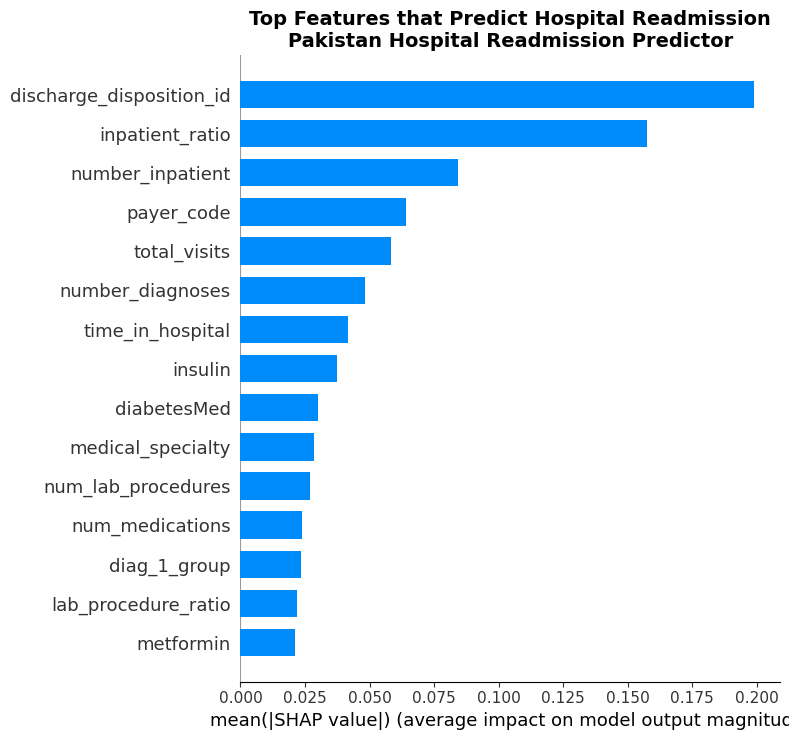

SHAP global chart saved!


In [40]:
import shap
import matplotlib.pyplot as plt
import joblib

print("Generating SHAP values...")

# Use a sample of 500 rows for speed
x_sample = X_test.iloc[:500]

# Generate SHAP values for CatBoost
explainer = shap.TreeExplainer(model_cat)
shap_values = explainer.shap_values(x_sample)

print("SHAP values generated")

# Global feature importance plot
plt.figure(figsize=(12,8))
shap.summary_plot(
    shap_values,
    x_sample,
    plot_type="bar",
    max_display=15,
    show=False,
)

plt.title("Top Features that Predict Hospital Readmission\nPakistan Hospital Readmission Predictor", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig('../static/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP global chart saved!")


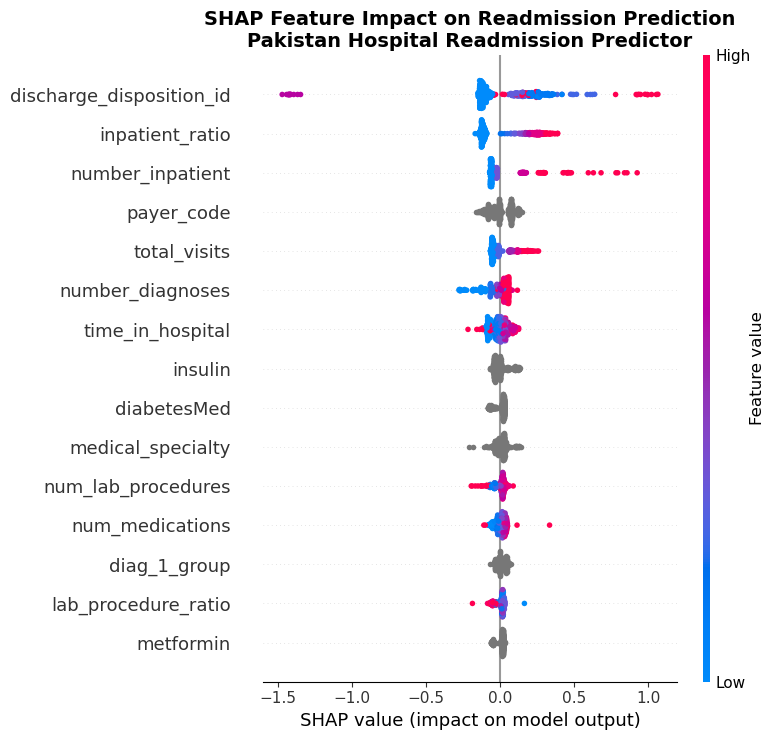

SHAP beeswarm chart saved!


In [38]:
# Beeswarm plot - more detailed and impressive
plt.figure(figsize=(12,8))
shap.summary_plot(
    shap_values,
    x_sample,
    max_display=15,
    show=False,
)

plt.title('SHAP Feature Impact on Readmission Prediction\nPakistan Hospital Readmission Predictor',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../static/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm chart saved!")

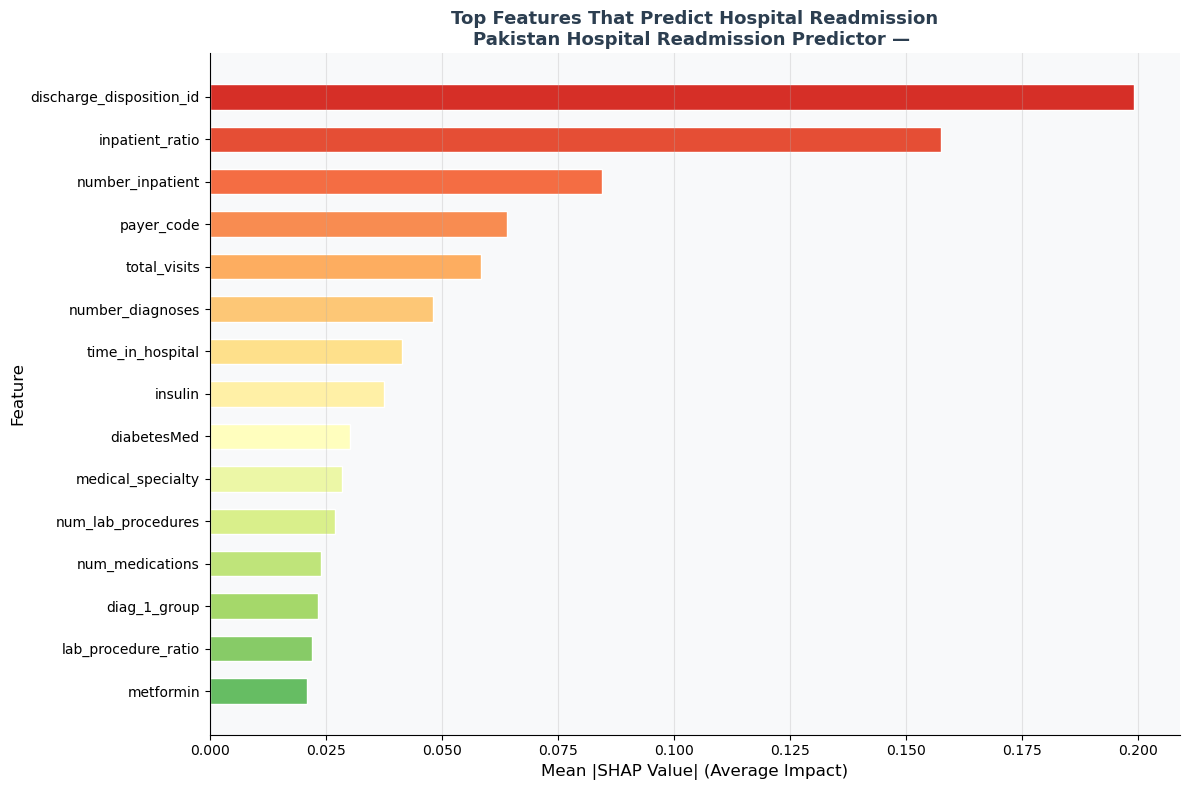

Beautiful SHAP chart saved!


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance from SHAP
shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=True).tail(15)

# Create colorful horizontal bar chart like your friend's
fig, ax = plt.subplots(figsize=(12, 8))

# Color gradient from green to red
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(shap_importance)))

bars = ax.barh(shap_importance['Feature'], shap_importance['Importance'],color=colors, edgecolor='white', height=0.6)

ax.set_xlabel('Mean |SHAP Value| (Average Impact)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top Features That Predict Hospital Readmission\nPakistan Hospital Readmission Predictor — ',fontsize=13, fontweight='bold', color='#2C3E50')

ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#FFFFFF')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../static/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Beautiful SHAP chart saved!")

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

# Reload data
df = pd.read_csv('../data/diabetic_data.csv')
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['encounter_id', 'patient_nbr', 'readmitted'], inplace=True)
df.replace('?', np.nan, inplace=True)

# Diagnosis grouping
def group_diagnosis(diag):
    try:
        diag = float(diag)
        if 390 <= diag <= 459: return 'Circulatory'
        elif 460 <= diag <= 519: return 'Respiratory'
        elif 520 <= diag <= 579: return 'Digestive'
        elif 250 <= diag < 251: return 'Diabetes'
        elif 800 <= diag <= 999: return 'Injury'
        else: return 'Other'
    except: return 'Other'

df['diag_1_group'] = df['diag_1'].apply(group_diagnosis)
df['diag_2_group'] = df['diag_2'].apply(group_diagnosis)
df['diag_3_group'] = df['diag_3'].apply(group_diagnosis)
df.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)

# Feature engineering
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df['emergency_ratio'] = df['number_emergency'] / (df['total_visits'] + 1)
df['inpatient_ratio'] = df['number_inpatient'] / (df['total_visits'] + 1)
df['medication_per_visit'] = df['num_medications'] / (df['total_visits'] + 1)
df['lab_procedure_ratio'] = df['num_lab_procedures'] / (df['time_in_hospital'] + 1)

# Handle missing values
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna('Unknown').astype(str)
num_cols = df.select_dtypes(exclude=['object']).columns.tolist()
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Features and target
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load saved model
model_cat = joblib.load('../models/readmission_model.pkl')

print("Everything reloaded!")
print(f"X_test shape: {X_test.shape}")

# Generate SHAP values
X_sample = X_test.iloc[:500]
explainer = shap.TreeExplainer(model_cat)
shap_values = explainer.shap_values(X_sample)

print("SHAP values generated!")

Everything reloaded!
X_test shape: (20354, 52)
SHAP values generated!


In [45]:
print("=" * 50)
print("DAY 3 COMPLETE!")
print("=" * 50)
print("Model: CatBoost Classifier")
print(f"AUC-ROC:   0.6835")
print(f"Accuracy:  73.58%")
print(f"Recall:    48.39%")
print(f"Threshold: 0.31")
print("\nFiles saved:")
print("  models/readmission_model.pkl")
print("  models/feature_names.pkl")
print("  models/best_threshold.pkl")
print("  static/shap_global.png")
print("  static/shap_beeswarm.png")
print("=" * 50)
print("Tomorrow - Day 4: Flask Web App!")
print("=" * 50)

DAY 3 COMPLETE!
Model: CatBoost Classifier
AUC-ROC:   0.6835
Accuracy:  73.58%
Recall:    48.39%
Threshold: 0.31

Files saved:
  models/readmission_model.pkl
  models/feature_names.pkl
  models/best_threshold.pkl
  static/shap_global.png
  static/shap_beeswarm.png
Tomorrow - Day 4: Flask Web App!
